<a href="https://colab.research.google.com/github/charan327/RandomtreesvsDecisiontree/blob/main/Copy_of_EDA_MovieLens_UI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If you run this notebook in Jupyter locally, set MOVIELENS_DIR to your extracted dataset folder.
# Example (Windows): r"C:\Users\Charan\Downloads\ml-latest-small"
# Example (Mac/Linux): "/Users/charan/Downloads/ml-latest-small"

MOVIELENS_DIR = ""  # <-- set this OR use the UI below

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# UI requires ipywidgets. If it fails, you can ignore UI and use manual cells below.
try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown, clear_output
    WIDGETS_AVAILABLE = True
except Exception as e:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not available here. You can still run the notebook without UI.")
    print("Error:", e)


In [ ]:
# Global variables to hold dataframes after loading
ratings = None
movies = None
tags = None

def load_movielens(folder: str):
    folder_path = Path(folder).expanduser().resolve()
    ratings_path = folder_path / "ratings.csv"
    movies_path = folder_path / "movies.csv"
    tags_path = folder_path / "tags.csv"

    if not ratings_path.exists() or not movies_path.exists():
        raise FileNotFoundError(
            f"Could not find ratings.csv and movies.csv in: {folder_path}\n"
            f"Found ratings.csv: {ratings_path.exists()} | movies.csv: {movies_path.exists()}\n"
            f"Tip: set MOVIELENS_DIR to your dataset folder or copy the correct path into the UI."
        )

    r = pd.read_csv(ratings_path)
    m = pd.read_csv(movies_path)
    t = pd.read_csv(tags_path) if tags_path.exists() else None
    return r, m, t

def basic_quality_checks(r: pd.DataFrame, m: pd.DataFrame, t: pd.DataFrame | None):
    out = {}
    out["ratings_shape"] = r.shape
    out["movies_shape"] = m.shape
    out["tags_shape"] = None if t is None else t.shape

    out["ratings_missing"] = r.isna().sum()
    out["movies_missing"] = m.isna().sum()
    out["tags_missing"] = None if t is None else t.isna().sum()

    out["ratings_duplicates"] = int(r.duplicated().sum())
    out["movies_duplicates"] = int(m.duplicated().sum())
    out["tags_duplicates"] = None if t is None else int(t.duplicated().sum())

    return out

def dataset_summary(r: pd.DataFrame):
    # number of unique users, movies, and total ratings
    n_users = r["userId"].nunique()
    n_movies = r["movieId"].nunique()
    n_ratings = len(r)
    sparsity = 1 - (n_ratings / (n_users * n_movies))
    return n_users, n_movies, n_ratings, sparsity

def plot_rating_distribution(r: pd.DataFrame):
    plt.figure()
    r["rating"].hist(bins=10)
    plt.title("Rating distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

def plot_ratings_per_user(r: pd.DataFrame):
    counts = r.groupby("userId")["movieId"].count()
    plt.figure()
    counts.hist(bins=50)
    plt.title("Ratings per user (user activity)")
    plt.xlabel("Number of ratings")
    plt.ylabel("Number of users")
    plt.show()
    return counts

def plot_ratings_per_movie(r: pd.DataFrame):
    counts = r.groupby("movieId")["userId"].count()
    plt.figure()
    counts.hist(bins=50)
    plt.title("Ratings per movie (popularity)")
    plt.xlabel("Number of ratings")
    plt.ylabel("Number of movies")
    plt.show()
    return counts

def simple_cleaning(r: pd.DataFrame, m: pd.DataFrame, t: pd.DataFrame | None):
    # Keep a copy
    r2 = r.copy()
    m2 = m.copy()
    t2 = None if t is None else t.copy()

    # Convert dtypes (safe, helps later)
    r2["userId"] = r2["userId"].astype(int)
    r2["movieId"] = r2["movieId"].astype(int)
    r2["rating"] = r2["rating"].astype(float)
    if "timestamp" in r2.columns:
        r2["timestamp"] = pd.to_datetime(r2["timestamp"], unit="s", errors="coerce")

    m2["movieId"] = m2["movieId"].astype(int)
    if "genres" in m2.columns:
        m2["genres"] = m2["genres"].fillna("")

    if t2 is not None:
        t2["userId"] = t2["userId"].astype(int)
        t2["movieId"] = t2["movieId"].astype(int)
        if "timestamp" in t2.columns:
            # MovieLens tags typically also have Unix timestamps
            t2["timestamp"] = pd.to_datetime(t2["timestamp"], unit="s", errors="coerce")
        if "tag" in t2.columns:
            t2["tag"] = t2["tag"].astype(str).fillna("")

    # Drop exact duplicate rows
    r2 = r2.drop_duplicates()
    m2 = m2.drop_duplicates()
    if t2 is not None:
        t2 = t2.drop_duplicates()

    return r2, m2, t2

def build_ui():
    if not WIDGETS_AVAILABLE:
        return

    path_box = widgets.Text(
        value=MOVIELENS_DIR,
        description="Dataset folder:",
        placeholder="Paste folder path containing ratings.csv and movies.csv",
        layout=widgets.Layout(width="80%")
    )
    load_btn = widgets.Button(description="Load dataset", button_style="primary")
    run_btn = widgets.Button(description="Run EDA + Plots", button_style="success")
    clean_btn = widgets.Button(description="Run Cleaning", button_style="warning")

    user_dropdown = widgets.Dropdown(options=[], description="User:", disabled=True)
    topn_slider = widgets.IntSlider(value=10, min=5, max=30, step=1, description="Top N:")
    show_user_btn = widgets.Button(description="Show user's top rated movies", button_style="info")

    output = widgets.Output()

    def on_load_clicked(_):
        nonlocal user_dropdown
        global ratings, movies, tags
        with output:
            clear_output()
            try:
                ratings, movies, tags = load_movielens(path_box.value.strip())
                display(Markdown("✅ **Dataset loaded successfully.**"))
                display(Markdown(f"- ratings: `{ratings.shape}`\n- movies: `{movies.shape}`\n- tags: `{None if tags is None else tags.shape}`"))

                # Populate user dropdown
                user_ids = sorted(ratings["userId"].unique().tolist())
                user_dropdown.options = user_ids[:500]  # limit for UI responsiveness
                user_dropdown.disabled = False
                display(Markdown("✅ User dropdown enabled (showing first 500 users for speed)."))
            except Exception as e:
                display(Markdown(f"❌ **Load failed:** {e}"))

    def on_run_clicked(_):
        global ratings, movies, tags
        with output:
            clear_output()
            if ratings is None or movies is None:
                display(Markdown("⚠️ Please load the dataset first."))
                return

            qc = basic_quality_checks(ratings, movies, tags)
            n_users, n_movies, n_ratings, sparsity = dataset_summary(ratings)

            display(Markdown("## ✅ Quick Summary"))
            display(Markdown(f"- Users: **{n_users:,}**\n- Movies: **{n_movies:,}**\n- Ratings: **{n_ratings:,}**\n- Sparsity (approx): **{sparsity:.4f}**"))

            display(Markdown("## ✅ Data Quality Checks"))
            display(Markdown(f"**Duplicates (rows):** ratings={qc['ratings_duplicates']} | movies={qc['movies_duplicates']} | tags={qc['tags_duplicates']}"))
            display(Markdown("**Missing values (top columns):**"))
            display(pd.DataFrame({
                "ratings_missing": qc["ratings_missing"],
            }).sort_values("ratings_missing", ascending=False).head(10))

            display(Markdown("## 📊 Key Plots"))
            plot_rating_distribution(ratings)
            plot_ratings_per_user(ratings)
            plot_ratings_per_movie(ratings)

            display(Markdown("## ✅ Notes (for supervision)"))
            display(Markdown(
                "- Ratings often skew higher (positive bias).\n"
                "- Ratings per user show sparsity (many users rate few items).\n"
                "- Ratings per movie show popularity bias (few movies dominate)."
            ))

    def on_clean_clicked(_):
        global ratings, movies, tags
        with output:
            clear_output()
            if ratings is None or movies is None:
                display(Markdown("⚠️ Please load the dataset first."))
                return
            before_r, before_m = ratings.shape, movies.shape
            ratings, movies, tags = simple_cleaning(ratings, movies, tags)
            after_r, after_m = ratings.shape, movies.shape
            display(Markdown("✅ **Cleaning complete.**"))
            display(Markdown(f"- ratings: {before_r} → {after_r}\n- movies: {before_m} → {after_m}"))
            display(Markdown("Applied: dtype fixes, timestamp conversion (if present), removed duplicates, filled missing genres."))

    def on_show_user_clicked(_):
        global ratings, movies
        with output:
            display(Markdown("---"))
            if ratings is None or movies is None:
                display(Markdown("⚠️ Please load the dataset first."))
                return
            uid = user_dropdown.value
            n = int(topn_slider.value)
            user_r = ratings[ratings["userId"] == uid].sort_values("rating", ascending=False).head(n)
            merged = user_r.merge(movies, on="movieId", how="left")[["userId", "movieId", "title", "genres", "rating"]]
            display(Markdown(f"### 🎬 Top rated movies for user **{uid}** (Top {n})"))
            display(merged.reset_index(drop=True))

    load_btn.on_click(on_load_clicked)
    run_btn.on_click(on_run_clicked)
    clean_btn.on_click(on_clean_clicked)
    show_user_btn.on_click(on_show_user_clicked)

    controls = widgets.VBox([
        path_box,
        widgets.HBox([load_btn, run_btn, clean_btn]),
        widgets.HBox([user_dropdown, topn_slider, show_user_btn])
    ])

    display(controls, output)

build_ui()


Output()

In [ ]:
!unzip ml-latest-small.zip


Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


## 2) Manual (No-UI) EDA Steps (Optional)
If you prefer not to use widgets, set `MOVIELENS_DIR` above and run the cells below.

In [ ]:
# ---- Manual load (optional) ----
if MOVIELENS_DIR:
    ratings, movies, tags = load_movielens(MOVIELENS_DIR)
    print("Loaded ratings:", ratings.shape)
    print("Loaded movies :", movies.shape)
    print("Loaded tags   :", None if tags is None else tags.shape)
else:
    print("Set MOVIELENS_DIR above or use the UI to load the dataset.")


Set MOVIELENS_DIR above or use the UI to load the dataset.


Users   : 610
Movies  : 9,724
Ratings : 100,836
Sparsity: 0.983

Duplicates (rows):
 - ratings: 0
 - movies : 0
 - tags   : 0

Missing values (ratings):


,0
userId,0
movieId,0
rating,0
timestamp,0


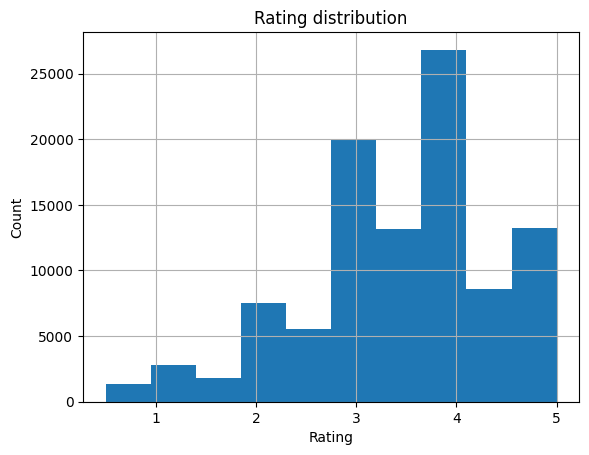

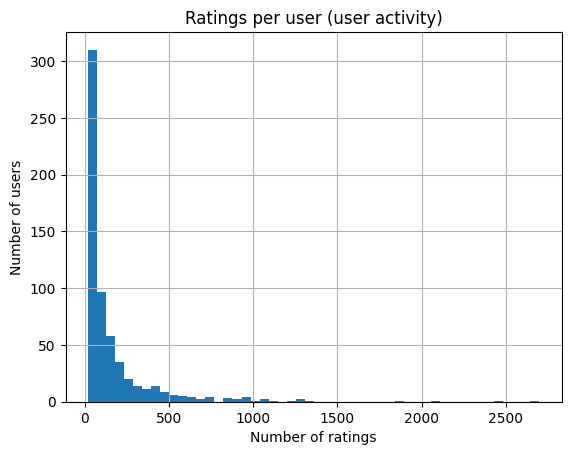

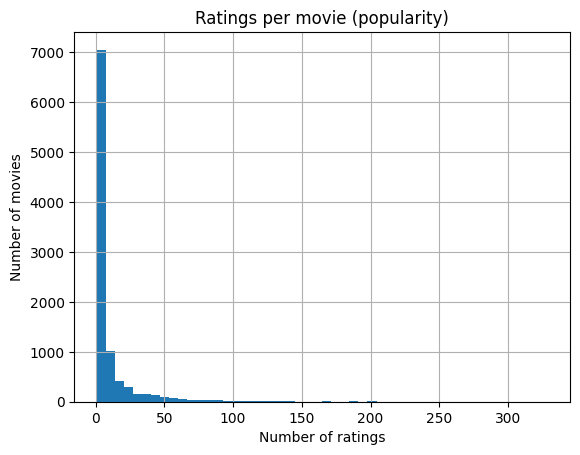

In [ ]:
# ---- Manual EDA (optional) ----
if ratings is not None and movies is not None:
    qc = basic_quality_checks(ratings, movies, tags)
    n_users, n_movies, n_ratings, sparsity = dataset_summary(ratings)

    print("Users   :", f"{n_users:,}")
    print("Movies  :", f"{n_movies:,}")
    print("Ratings :", f"{n_ratings:,}")
    print("Sparsity:", round(sparsity, 4))

    print("\nDuplicates (rows):")
    print(" - ratings:", qc["ratings_duplicates"])
    print(" - movies :", qc["movies_duplicates"])
    print(" - tags   :", qc["tags_duplicates"])

    print("\nMissing values (ratings):")
    display(qc["ratings_missing"].sort_values(ascending=False).head(10))

    plot_rating_distribution(ratings)
    plot_ratings_per_user(ratings)
    plot_ratings_per_movie(ratings)
else:
    print("Load the dataset first.")


## 3) Literature Review — Starter List (Bring this to supervision)

You can mention that you've started reading these foundational sources and will expand the review:

- Ricci, Rokach, Shapira (2011). *Recommender Systems Handbook*  
- Koren, Bell, Volinsky (2009). *Matrix Factorization Techniques for Recommender Systems*  
- Aggarwal (2016). *Recommender Systems: The Textbook*  
- (Optional) A paper/blog on explainability in recommender systems (XAI)

**In your report**, you will relate these to:
- collaborative filtering
- content-based filtering
- hybrid recommendation
- explainability


## 4) Next Steps (After EDA)

1. Finalise cleaning decisions (e.g., minimum ratings per user/movie for stable training)
2. Build baselines:
   - Most-popular recommender
   - Item-based similarity recommender
3. Evaluate baselines with ranking metrics (Precision@K, Recall@K, NDCG@K)
4. Implement matrix factorisation collaborative filtering
5. Add TMDb metadata to form a hybrid model + simple explanations

✅ For the next supervision: show your notebook + 2–3 plots + what you learned about sparsity & popularity bias.
